In [1]:
import pandas as pd
# import utils as uti
from utils import results as res
import matplotlib.pyplot as plt
import pickle

In [2]:
df_train = pd.read_pickle("../data/01_df_train.pkl")
df_test = pd.read_pickle("../data/01_df_test.pkl")

In [3]:
walds = pd.read_pickle("../data/01_df_walds.pkl")

In [4]:
with open("../data/02_dic_models.pkl", "rb") as file:
    models = pickle.load(file)

In [5]:
walds.head()

,var,wald,corr,corr ind
0,checking_account_status_woe,81.374162,0.243345,False
1,duration_months_woe,40.639132,0.23402,False
2,credit_history_woe,40.399187,0.376188,True
3,savings_account_bonds_woe,30.802473,0.243345,False
4,credit_amount_woe,28.469128,0.23402,False


In [6]:
models.keys()

dict_keys(['xgb woe', 'logi', 'xgb raw'])

# predict logistic

In [7]:
import statsmodels.api as sm

In [8]:
models['logi'].params.index.tolist()[1:]

['checking_account_status_woe',
 'duration_months_woe',
 'savings_account_bonds_woe',
 'credit_amount_woe',
 'employment_since_woe',
 'other_installment_plans_woe',
 'purpose_woe',
 'installment_rate_percent_woe']

In [9]:
tmp = sm.add_constant(
    df_train[models['logi'].params.index.tolist()[1:]],
    has_constant="add"
)

df_train['logi'] = models['logi'].predict(tmp)

In [10]:
tmp = sm.add_constant(
    df_test[models['logi'].params.index.tolist()[1:]],
    has_constant="add"
)

df_test['logi'] = models['logi'].predict(tmp)

# predict XGB WoE

In [11]:
df_train['xgb woe'] = models['xgb woe'].predict_proba(df_train[models['xgb woe'].get_booster().feature_names])[:, 1]

In [12]:
df_test['xgb woe'] = models['xgb woe'].predict_proba(df_test[models['xgb woe'].get_booster().feature_names])[:, 1]

# predict XGB raw

## onehot data

In [13]:
import joblib

preprocessor = joblib.load("../data/02b_dummy_preprocessor.pkl")

In [14]:
train_array = preprocessor.transform(df_train)
test_array = preprocessor.transform(df_test)

In [15]:
pre_names = preprocessor.get_feature_names_out()

X_train = pd.DataFrame(
    train_array,
    columns=pre_names,
    index=df_train.index
)

In [16]:
pre_names = preprocessor.get_feature_names_out()

X_test = pd.DataFrame(
    test_array,
    columns=pre_names,
    index=df_test.index
)

In [17]:
df_train['xgb raw'] = models['xgb raw'].predict_proba(X_train[models['xgb raw'].get_booster().feature_names])[:, 1]

In [18]:
df_test['xgb raw'] = models['xgb raw'].predict_proba(X_test[models['xgb raw'].get_booster().feature_names])[:, 1]

# perfect prediction

In [19]:
df_train.sort_values(by='bad', inplace= True)
df_train['perf'] = range(len(df_train))

In [20]:
df_test.sort_values(by='bad', inplace=True)
df_test['perf'] = range(len(df_test))

# compare performance

In [21]:
df_train.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,employment_since,installment_rate_percent,personal_status_sex,other_debtors_guarantors,...,employment_since_woe,property_woe,other_installment_plans_woe,housing_woe,job_woe,telephone_woe,logi,xgb woe,xgb raw,perf
749,no account,15,current credit paid,used car,3029,lt100 DM,4 to 7 years,2,male single,none,...,-0.400846,0.033661,-0.149123,-0.200495,-0.048159,0.074108,0.023146,0.016314,0.038509,0
417,lt0 DM,18,past payment delays,education,8471,unknown or no savings,1 to 4 years,1,female married or divorced,none,...,-0.113329,0.033661,-0.149123,0.424441,-0.048159,-0.112478,0.386030,0.503296,0.319683,1
442,0 to 200 DM,20,past payment delays,other,2629,lt100 DM,1 to 4 years,2,male single,none,...,-0.113329,0.033661,0.567338,-0.200495,-0.048159,-0.112478,0.511317,0.424197,0.421171,2
687,0 to 200 DM,36,past payment delays,new car,2862,100 to 500 DM,ge7 years,4,male single,none,...,-0.187599,0.685657,-0.149123,0.470820,-0.048159,0.074108,0.505636,0.592822,0.508784,3
75,lt0 DM,12,critical or other credit,used car,1526,lt100 DM,ge7 years,4,male single,none,...,-0.187599,0.685657,-0.149123,0.470820,0.233288,0.074108,0.187529,0.210965,0.284698,4


In [22]:
df_test.head()

,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account_bonds,employment_since,installment_rate_percent,personal_status_sex,other_debtors_guarantors,...,employment_since_woe,property_woe,other_installment_plans_woe,housing_woe,job_woe,telephone_woe,logi,xgb woe,xgb raw,perf
30,0 to 200 DM,18,current credit paid,business,1913,ge1000 DM,lt1 year,3,male married or widowed,none,...,0.608406,-0.511447,0.567338,-0.200495,-0.048159,-0.112478,0.546234,0.272591,0.283779,0
793,ge200 DM,24,current credit paid,furniture or equipment,2892,lt100 DM,ge7 years,3,male divorced,none,...,-0.187599,0.685657,-0.149123,0.470820,-0.048159,0.074108,0.216613,0.410012,0.504085,1
142,lt0 DM,27,current credit paid,radio or TV,3416,lt100 DM,1 to 4 years,3,male single,none,...,-0.113329,0.033661,-0.149123,-0.200495,0.233288,0.074108,0.257912,0.364809,0.530577,2
657,no account,48,current credit paid,radio or TV,10222,unknown or no savings,4 to 7 years,4,male single,none,...,-0.400846,0.033661,0.567338,-0.200495,-0.048159,-0.112478,0.194496,0.191594,0.252120,3
477,ge200 DM,24,current credit paid,radio or TV,5152,lt100 DM,4 to 7 years,4,male single,none,...,-0.400846,0.033661,0.567338,-0.200495,-0.048159,0.074108,0.417494,0.490760,0.439378,4


In [23]:
models_names = {
    "Logistic regression": "logi",
    "XGBoost WoE": "xgb woe",
    "XGBoost": "xgb raw",
    "Perfect": "perf"    
}

## ROC

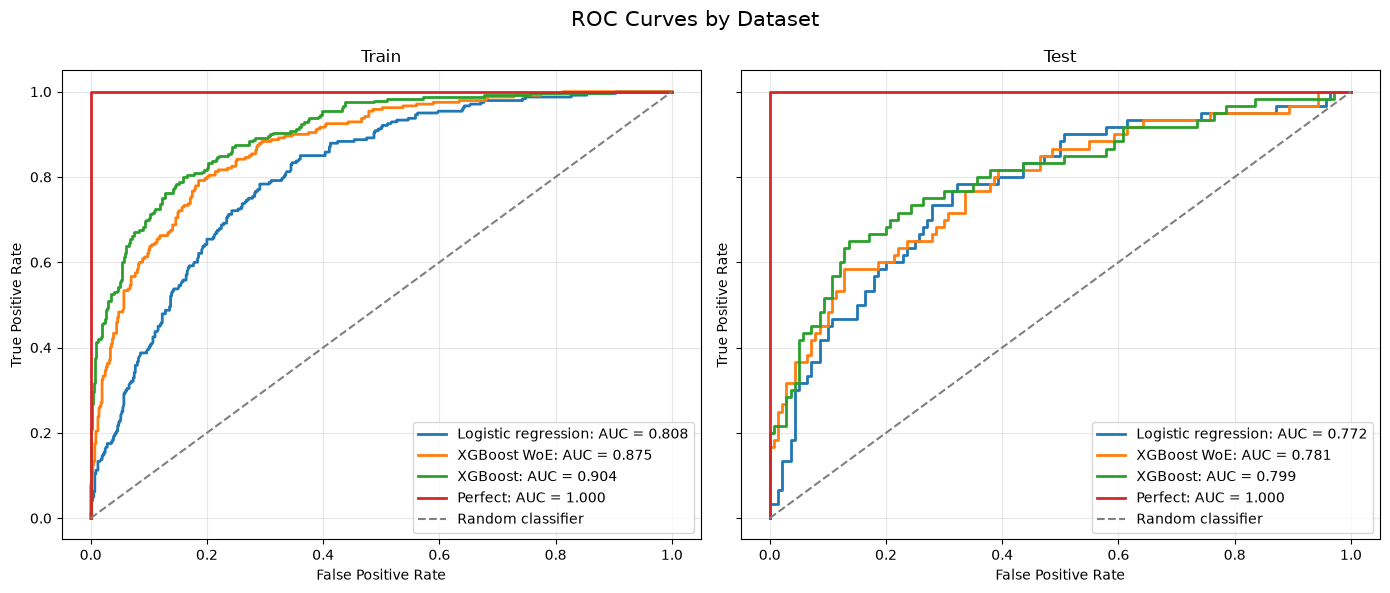

In [24]:
res.roc_plot(
    df_1=df_train,
    df_2=df_test,
    models=models_names,
    target_name="bad"
)

## Lift

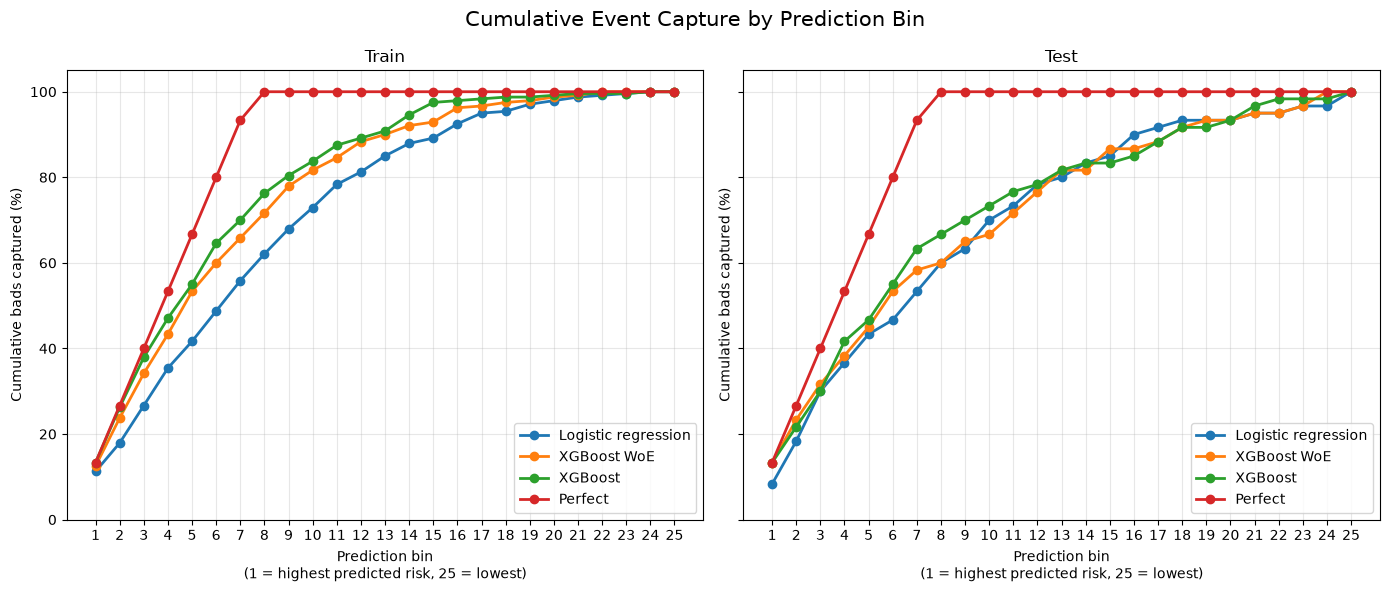

In [25]:
res.cumulative_event_rate_plot(
    df_1=df_train,
    df_2=df_test,
    models=models_names,
    target_name="bad",
    n_bins=25
)

## KS

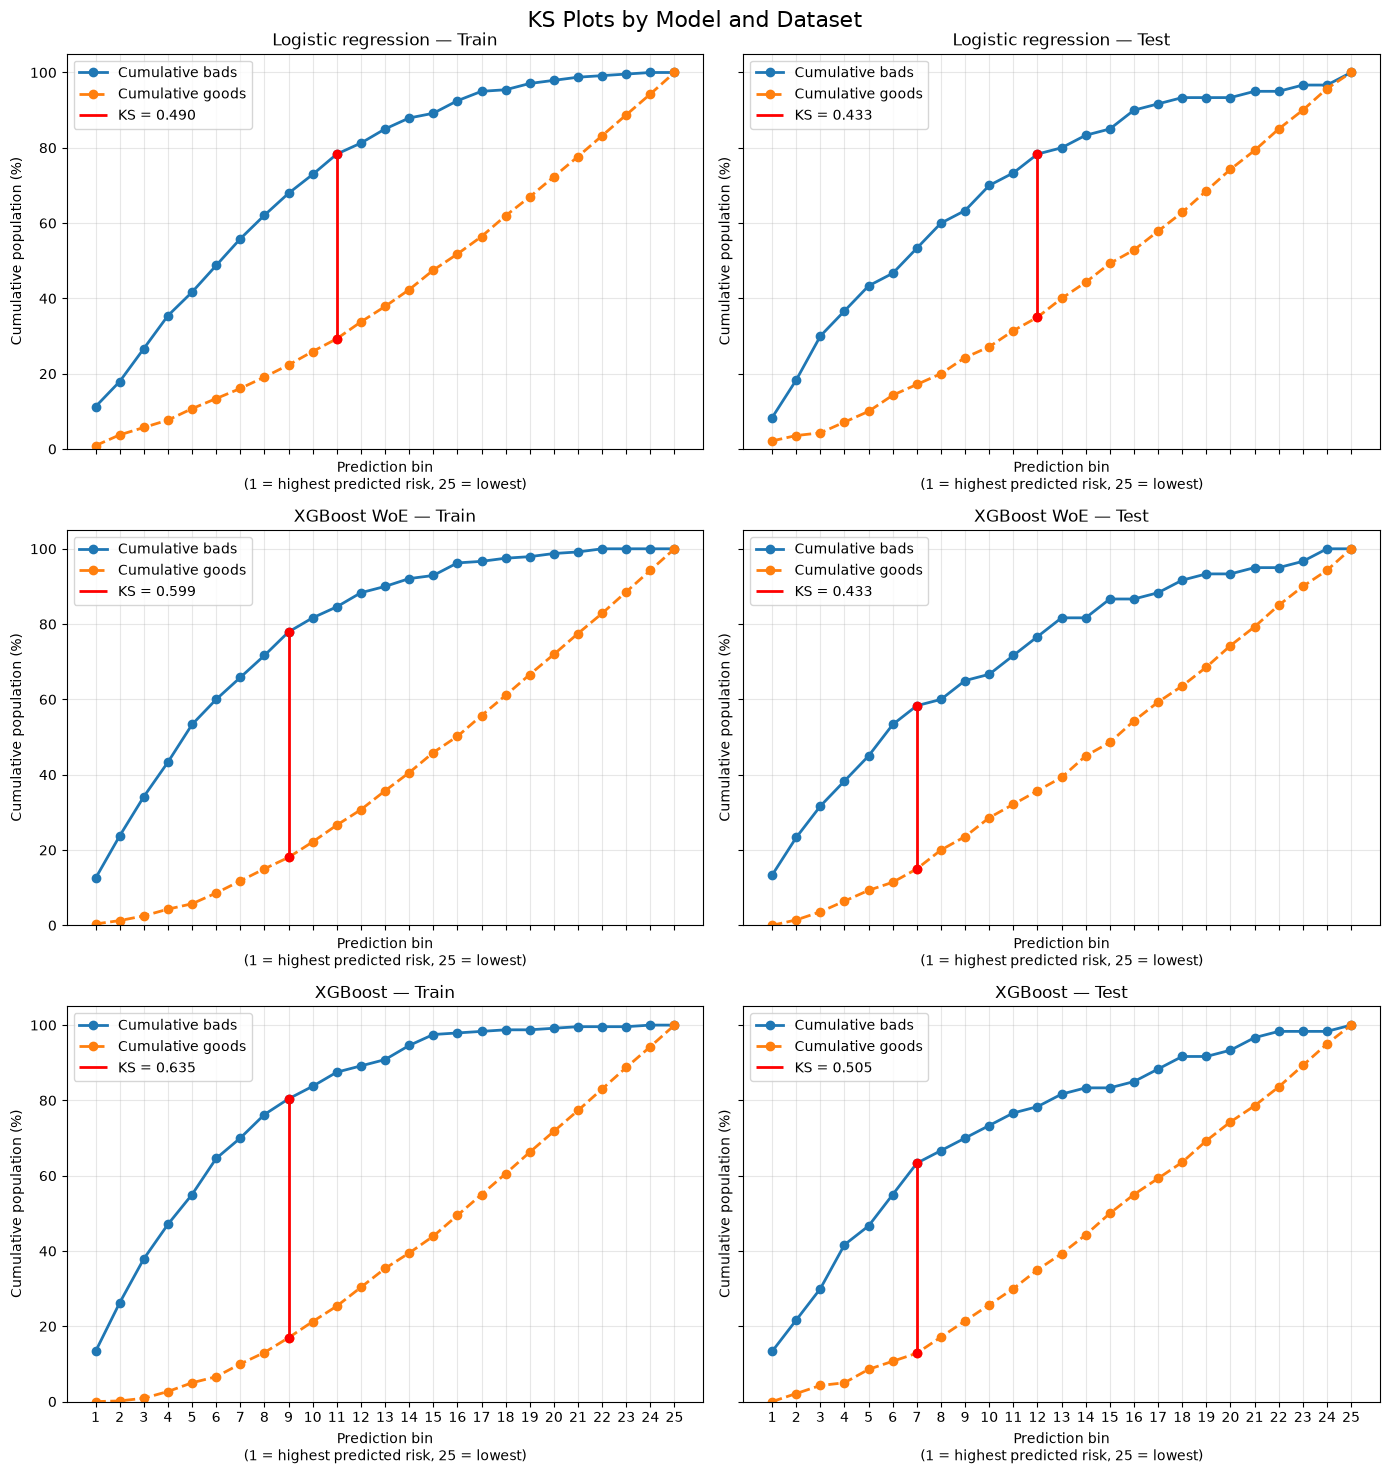

In [26]:
res.ks_plot(
    df_1=df_train,
    df_2=df_test,
    models=dict(list(models_names.items())[:-1]),
    target_name="bad",
    n_bins=25
)

# calibration

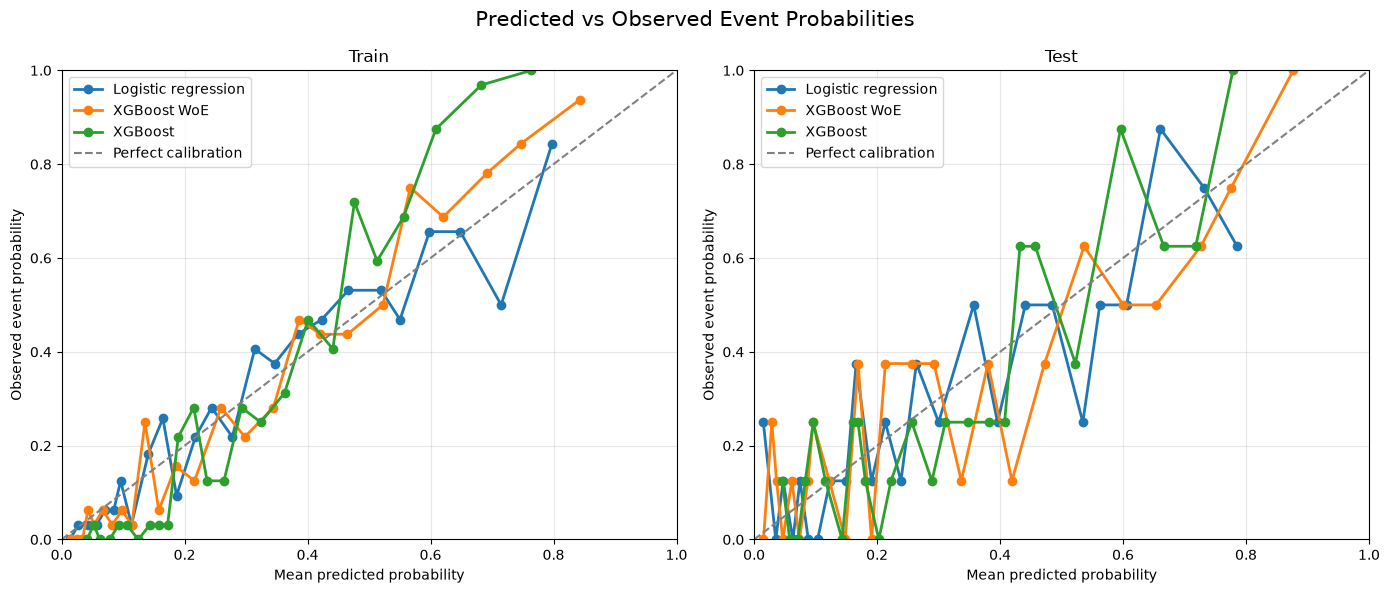

In [27]:
res.calibration_plot(
    df_1=df_train,
    df_2=df_test,
    models=dict(list(models_names.items())[:-1]),
    target_name="bad",
    n_bins=25
)

# save predictions

In [28]:
df_train['sample'] = 'train'
df_test['sample'] = 'test'

In [29]:
results = pd.concat(
    [df_train, df_test],
    ignore_index=True
)

In [30]:
results.to_pickle("../data/03_df_results_df.pkl")